In [2]:
import mpmath as mp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

In [3]:
mp.mp.dps = 30

def set_precision(dps: int):
    mp.mp.dps = dps


def mpmat_zeros(n: int, m: int = None):
    if m is None:
        m = n
    return mp.matrix(n, m)


In [4]:
def identity(n: int):
    I = mp.matrix(n, n)
    for i in range(n):
        I[i, i] = mp.mpf("1")
    return I


def hermitize(H: mp.matrix):
    return (H + H.transpose_conj()) / mp.mpf("2")


def submatrix(A: mp.matrix, rows, cols):
    out = mp.matrix(len(rows), len(cols))
    for i, r in enumerate(rows):
        for j, c in enumerate(cols):
            out[i, j] = A[r, c]
    return out


def diag_from_list(vals):
    n = len(vals)
    M = mp.matrix(n, n)
    for i, v in enumerate(vals):
        M[i, i] = v
    return M


def matrix_to_nested_float_lists(M: mp.matrix):
    return [[float(mp.re(M[i, j])) for j in range(M.cols)] for i in range(M.rows)]


def to_float_list(xs):
    return [float(x) for x in xs]


def col(results, idx):
    return [row[idx] for row in results]


def min_positive(xs):
    positives = [x for x in xs if x > 0]
    return min(positives) if positives else None


def sorted_unique(xs):
    return sorted(set(xs), key=lambda z: float(z))


def reshape_flat(flat, nrows, ncols):
    if len(flat) != nrows * ncols:
        raise ValueError(f"Cannot reshape list of length {len(flat)} into ({nrows}, {ncols})")
    return [flat[r * ncols:(r + 1) * ncols] for r in range(nrows)]


def clamp_nonpositive_to_min_positive(y):
    y2 = list(y)
    mp_min = min_positive(y2)
    if mp_min is None:
        return y2
    return [mp_min if val <= 0 else val for val in y2]


def make_real_symmetric(H: mp.matrix, tol=None, verbose=False):
    """
    Convert a nearly-Hermitian matrix into a real symmetric matrix
    by dropping tiny imaginary parts.

    This is needed because mp.eigsy expects a real symmetric matrix,
    not a complex Hermitian matrix with zero/tiny imaginary parts.
    """
    Hh = hermitize(H)
    n = Hh.rows

    if tol is None:
        # tolerance tied to working precision
        tol = mp.mpf(10) ** (-(mp.mp.dps - 20))

    Hr = mp.matrix(n, n)

    max_im = mp.mpf("0")
    max_herm_violation = mp.mpf("0")

    for i in range(n):
        for j in range(n):
            hij = Hh[i, j]

            im_abs = abs(mp.im(hij))
            if im_abs > max_im:
                max_im = im_abs

            herm_violation = abs(hij - mp.conj(Hh[j, i]))
            if herm_violation > max_herm_violation:
                max_herm_violation = herm_violation

            Hr[i, j] = mp.re(hij)

    if verbose:
        print(f"max imaginary part      = {max_im}")
        print(f"max Hermitian violation = {max_herm_violation}")
        print(f"tolerance               = {tol}")

    if max_im > tol:
        raise ValueError(
            f"Matrix is not sufficiently real for mp.eigsy: "
            f"max imaginary part = {max_im}, tolerance = {tol}"
        )

    return Hr


def matrix_diagnostics(H: mp.matrix):
    """
    Quick diagnostic printout for debugging matrices before diagonalization.
    """
    Hh = hermitize(H)
    n = Hh.rows

    max_im = mp.mpf("0")
    max_herm_violation = mp.mpf("0")

    for i in range(n):
        for j in range(n):
            max_im = max(max_im, abs(mp.im(Hh[i, j])))
            max_herm_violation = max(
                max_herm_violation,
                abs(Hh[i, j] - mp.conj(Hh[j, i]))
            )

    print("max imaginary part      =", max_im)
    print("max Hermitian violation =", max_herm_violation)

In [5]:
def ladder_ops(N: int):
    a = mp.matrix(N, N)
    adag = mp.matrix(N, N)

    for n in range(1, N):
        a[n - 1, n] = mp.sqrt(n)

    for n in range(0, N - 1):
        adag[n + 1, n] = mp.sqrt(n + 1)

    return a, adag



In [6]:
def ho_operators(N: int, omega):
    omega = mp.mpf(omega)
    a, adag = ladder_ops(N)
    phi = (a + adag) / mp.sqrt(2 * omega)
    pi = 1j * mp.sqrt(omega / 2) * (adag - a)
    return phi, pi, a, adag


In [7]:
def build_H0(N: int, omega):
    omega = mp.mpf(omega)
    phi, pi, _, _ = ho_operators(N, omega)
    return mp.mpf("0.5") * (pi * pi) + mp.mpf("0.5") * omega**2 * (phi * phi)


def build_V(N: int, omega, lam):
    omega = mp.mpf(omega)
    lam = mp.mpf(lam)
    phi, _, _, _ = ho_operators(N, omega)
    phi2 = phi * phi
    phi4 = phi2 * phi2
    V_mass = mp.mpf("0.5") * (mp.mpf("1.0") - omega**2) * phi2
    V_x4 = (lam / mp.mpf("24.0")) * phi4
    return V_mass + V_x4


def build_full_H(N: int, omega, lam):
    return build_H0(N, omega) + build_V(N, omega, lam)


In [8]:
def indices_below_Emax(omega, Emax, N_uv: int):
    omega = mp.mpf(omega)
    Emax = mp.mpf(Emax)

    n = list(range(N_uv))
    En = [omega * (k + mp.mpf("0.5")) for k in n]
    P = [k for k, E in enumerate(En) if E <= Emax]
    Q = [k for k, E in enumerate(En) if E > Emax]
    return P, Q, En

In [9]:
def naive_Heff(N_uv: int, omega, lam, Emax, hermitianize=True):
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    H0_PP = submatrix(H0, P, P)
    V_PP = submatrix(V, P, P)

    Heff = H0_PP + V_PP
    if hermitianize:
        Heff = hermitize(Heff)

    return Heff, P, Q, H0, V


def htet_Heff_O_V2(N_uv: int, omega, lam, Emax, hermitianize=True):
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    H0_PP = submatrix(H0, P, P)
    V_PP = submatrix(V, P, P)
    V_PQ = submatrix(V, P, Q)
    V_QP = submatrix(V, Q, P)

    Heff = H0_PP + V_PP
    H2 = mp.matrix(nP, nP)

    EP = [En[i] for i in P]
    EQ = [En[i] for i in Q]

    for f in range(nP):
        Ef = EP[f]
        inv = [1 / (Ef - Eqa) for Eqa in EQ]
        for i in range(nP):
            s = mp.mpc("0")
            for a in range(len(Q)):
                s += V_PQ[f, a] * inv[a] * V_QP[a, i]
            H2[f, i] = s

    Heff = Heff + H2
    if hermitianize:
        Heff = hermitize(Heff)

    return Heff, P, Q, H0, V


def htet_Heff_O_V3(N_uv: int, omega, lam, Emax, hermitianize=True):
    Heff2, P, Q, H0, V = htet_Heff_O_V2(N_uv, omega, lam, Emax)
    _, _, En = indices_below_Emax(omega, Emax, N_uv)

    nP = len(P)
    nQ = len(Q)

    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")
    if nQ == 0:
        return Heff2, P, Q, H0, V

    V_PP = submatrix(V, P, P)
    V_PQ = submatrix(V, P, Q)
    V_QP = submatrix(V, Q, P)
    V_QQ = submatrix(V, Q, Q)

    H3 = mp.matrix(nP, nP)

    EP = [En[i] for i in P]
    EQ = [En[i] for i in Q]

    A = mp.matrix(nP, nQ)
    for a in range(nP):
        for b in range(nQ):
            A[a, b] = V_PQ[a, b] / (EP[a] - EQ[b])

    for f in range(nP):
        Ef = EP[f]
        inv_f = [1 / (Ef - Eqa) for Eqa in EQ]

        # first term
        tmp_b = [mp.mpc("0") for _ in range(nQ)]
        for b in range(nQ):
            s = mp.mpc("0")
            for a in range(nQ):
                s += V_PQ[f, a] * inv_f[a] * V_QQ[a, b]
            tmp_b[b] = s

        term1_row = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for b in range(nQ):
                s += tmp_b[b] * inv_f[b] * V_QP[b, i]
            term1_row[i] = s

        # second term
        s_b = [mp.mpc("0") for _ in range(nQ)]
        for b in range(nQ):
            s = mp.mpc("0")
            for a in range(nP):
                s += V_PP[f, a] * A[a, b]
            s_b[b] = s

        term2_row = [mp.mpc("0") for _ in range(nP)]
        for i in range(nP):
            s = mp.mpc("0")
            for b in range(nQ):
                s += s_b[b] * inv_f[b] * V_QP[b, i]
            term2_row[i] = s

        for i in range(nP):
            H3[f, i] = term1_row[i] - term2_row[i]

    Heff3 = Heff2 + H3
    if hermitianize:
        Heff = hermitize(Heff)

    return Heff3, P, Q, H0, V

In [10]:
def ground_state_energy_from_matrix(
    H,
    hermitian=True,
    tol=None,
    verbose=False,
    imag_tol=mp.mpf("1e-20"),
    select="smallest_real"
):
    if hermitian:
        Hr = make_real_symmetric(H, tol=tol, verbose=verbose)
        evals, _ = mp.eigsy(Hr)
        evals = list(evals)
        return evals[0], evals
    else:
        return ground_state_energy_nonhermitian(
            H,
            imag_tol=imag_tol,
            select=select
        )



In [11]:
def ground_state_energy_nonhermitian(
    H,
    imag_tol=mp.mpf("1e-20"),
    select="smallest_real"
):
    evals, evec_r = mp.eig(H, left=False, right=True)
    evals = list(evals)

    # keep finite eigenvalues
    evals = [ev for ev in evals if mp.isfinite(ev)]

    if not evals:
        raise ValueError("No finite eigenvalues found.")

    if select == "smallest_real":
        # primary rule: choose the eigenvalue with smallest real part
        # among those with acceptably small imaginary parts if possible
        nearly_real = [ev for ev in evals if abs(mp.im(ev)) <= imag_tol]

        if nearly_real:
            chosen = min(nearly_real, key=lambda z: mp.re(z))
        else:
            # fallback: choose the one with smallest real part anyway
            chosen = min(evals, key=lambda z: mp.re(z))

    elif select == "min_abs_imag_then_real":
        chosen = min(evals, key=lambda z: (abs(mp.im(z)), mp.re(z)))

    else:
        raise ValueError(f"Unknown selection rule: {select}")

    return chosen, evals

In [21]:
def acceptable_eigenvalue(ev, rel_imag_tol=mp.mpf("1e-10"), abs_imag_tol=mp.mpf("1e-20")):
    return abs(mp.im(ev)) <= max(abs_imag_tol, rel_imag_tol * max(1, abs(mp.re(ev))))

def run_energy_scan(
    heff: str,
    omega=1.0,
    lam=1.0,
    Emax_list=(6.0, 7.0, 8.0, 9.0, 10.0),
    Known_E=1.0,
    print_table=True,
    hermitianize=True,
    imag_tol=mp.mpf("1e-20")
):
    results = []

    if print_table:
        print(f"omega={omega}  lambda={lam}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)")
        print("-" * 90)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    add_dict = {
        "H1": 8,
        "H2": 12,
        "H3": 16
    }

    Known_E = mp.mpf(Known_E)

    for Emax in Emax_list:
        Emax_mp = mp.mpf(Emax)
        N_uv = int(mp.floor(Emax_mp)) + add_dict[heff]

        H_full = build_full_H(N_uv, omega, lam)
        P, Q, En = indices_below_Emax(omega, Emax_mp, N_uv)
        nP = len(P)

        H_raw = submatrix(H_full, P, P)
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax_mp, hermitianize=hermitianize)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet, hermitian=hermitianize, imag_tol=imag_tol)

        E_phys = mp.re(E0_htet)
        diff = Known_E - E_phys
        percentage_error = 100 * abs(diff / Known_E)
        imag_part = abs(mp.im(E0_htet))

        if not acceptable_eigenvalue(E0_htet):
            percentage_error = mp.nan

        row = [Emax_mp, nP, E0_raw, E0_htet, percentage_error, diff, imag_part]
        results.append(row)

        if print_table:
            print(
                f"{float(Emax_mp):6.2f} | {nP:6d} | "
                f"{mp.nstr(mp.re(E0_raw), 12)},{mp.nstr(mp.im(E0_raw), 3)} | "
                f"{mp.nstr(mp.re(E0_htet), 12)},{mp.nstr(mp.im(E0_htet), 3)} | "
                f"{mp.nstr(percentage_error, 6)}"
            )

    results = [r for r in results if r[4] != 0]
    return results


def run_omega_scan(
    heff: str,
    omega_list=(1.0, 2.0, 3.0, 4.0, 5.0),
    lam=1.0,
    N_uv=200,
    Emax=50.0,
    Known_E=1.0,
    print_table=True,
    hermitianize=True,
    imag_tol=mp.mpf("1e-20")
):
    results = []

    if print_table:
        print(f"lambda(Cohen)={lam}")
        print("Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error | omega")
        print("-" * 90)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    Emax = mp.mpf(Emax)
    Known_E = mp.mpf(Known_E)

    for omega in omega_list:
        omega_mp = mp.mpf(omega)

        H_full = build_full_H(N_uv, omega_mp, lam)
        P, Q, En = indices_below_Emax(omega_mp, Emax, N_uv)
        nP = len(P)

        H_raw = submatrix(H_full, P, P)
        E0_raw, _ = ground_state_energy_from_matrix(H_raw)

        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega_mp, lam, Emax, hermitianize=hermitianize)
        E0_htet, _ = ground_state_energy_from_matrix(H_htet, hermitian=hermitianize, imag_tol=imag_tol)

        E_phys = mp.re(E0_htet)
        diff = Known_E - E_phys
        percentage_error = 100 * abs(diff / Known_E)
        imag_part = abs(mp.im(E0_htet))

        if not acceptable_eigenvalue(E0_htet):
            percentage_error = mp.nan

        row = [Emax, nP, E0_raw, E0_htet, percentage_error, omega_mp, diff]
        results.append(row)

        if print_table:
            print(
                f"{float(Emax):6.2f} | {nP:6d} | "
                f"{mp.nstr(mp.re(E0_raw), 12)},{mp.nstr(mp.im(E0_raw), 3)} | "
                f"{mp.nstr(mp.re(E0_htet), 12)},{mp.nstr(mp.im(E0_htet), 3)} | "
                f"{mp.nstr(percentage_error, 6)} | {mp.nstr(omega_mp, 8)}"
            )

    results = [r for r in results if r[4] != 0]
    return results


def run_emax_omega_scan(
    heff: str,
    omega_list,
    lam=1.0,
    Emax_list=(6.0, 7.0, 8.0, 9.0, 10.0),
    Known_E=1.0,
    print_table=True,
    hermitianize=True,
    imag_tol=mp.mpf("1e-20")
):
    results = []

    if print_table:
        print(f"lambda(Cohen)={lam}")
        print("Emax | omega | percentage error")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    add_dict = {"H1": 8, "H2": 12, "H3": 16}
    Known_E = mp.mpf(Known_E)

    for Emax in Emax_list:
        Emax_mp = mp.mpf(Emax)
        for omega in omega_list:
            omega_mp = mp.mpf(omega)
            N_uv = int(mp.floor(Emax_mp)) + add_dict[heff]

            H_full = build_full_H(N_uv, omega_mp, lam)
            P, Q, En = indices_below_Emax(omega_mp, Emax_mp, N_uv)

            if len(P) == 0:
                continue

            H_raw = submatrix(H_full, P, P)
            E0_raw, _ = ground_state_energy_from_matrix(H_raw)

            H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega_mp, lam, Emax_mp, hermitianize=hermitianize)
            E0_htet, _ = ground_state_energy_from_matrix(H_htet, hermitian=hermitianize, imag_tol=imag_tol)

            E_phys = mp.re(E0_htet)
            diff = Known_E - E_phys
            percentage_error = 100 * abs(diff / Known_E)
            imag_part = abs(mp.im(E0_htet))

            if not acceptable_eigenvalue(E0_htet):
                percentage_error = mp.nan

            results.append([Emax_mp, omega_mp, percentage_error, diff])

            if print_table:
                print(f"{float(Emax_mp):6.2f} | {float(omega_mp):8.4f} | {mp.nstr(percentage_error, 6)}")

    errors = [r[2] for r in results]
    nonzero_errors = [e for e in errors if e > 0]

    if nonzero_errors:
        min_nonzero = min(nonzero_errors)
        for r in results:
            if r[2] == 0:
                r[2] = min_nonzero

    return results

In [22]:
E0 = mp.mpf("0.52773612731410831269035109114701621561393954399308")
nQ_list = (2, 3, 4, 5, 6, 7, 8, 9)

In [23]:
omega_list = [mp.mpf("0.01") + mp.mpf(i) * mp.mpf("0.5") for i in range(10)]
nQ = 3
Emax = 40
H_list = ["H1", "H2", "H3"]
Emax_list = [8, 16, 32]
fontsize = 12

In [24]:
N_uv1 = int(Emax) + 8
N_uv2 = int(Emax) + 12
N_uv3 = int(Emax) + 16

O_results_H1 = run_omega_scan(
    heff="H1",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv1,
    Emax=Emax,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

O_results_H2 = run_omega_scan(
    heff="H2",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv2,
    Emax=Emax,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

O_results_H3 = run_omega_scan(
    heff="H3",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv3,
    Emax=Emax,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)




lambda(Cohen)=1.0
Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error | omega
------------------------------------------------------------------------------------------
 40.00 |     48 | 1.60469646525,0.0 | 1.60469646525,0.0 | 204.072 | 0.01
 40.00 |     48 | 0.527736127314,0.0 | 0.527736127314,0.0 | 1.8786e-13 | 0.51
 40.00 |     40 | 0.527736127314,0.0 | 0.527736127314,0.0 | 2.96452e-19 | 1.01
 40.00 |     26 | 0.527736127314,0.0 | 0.527736127314,0.0 | 1.44195e-16 | 1.51
 40.00 |     20 | 0.527736127314,0.0 | 0.527736127314,0.0 | 9.18663e-13 | 2.01
 40.00 |     16 | 0.527736142858,0.0 | 0.527736142858,0.0 | 2.94538e-6 | 2.51
 40.00 |     13 | 0.527750570569,0.0 | 0.527750570569,0.0 | 0.00273683 | 3.01
 40.00 |     11 | 0.528310656043,0.0 | 0.528310656043,0.0 | 0.108867 | 3.51
 40.00 |     10 | 0.53387572793,0.0 | 0.53387572793,0.0 | 1.16338 | 4.01
 40.00 |      9 | 0.539960133435,0.0 | 0.539960133435,0.0 | 2.31631 | 4.51
lambda(Cohen)=1.0
Emax | dim(P) | E0_raw (Re,Im

best error for H3 is 2.13159363217892508919662627521e-15
best error for H2 is 1.54574143149599505993611726702e-15
best error for H1 is 2.96452220715356344485481548939e-19


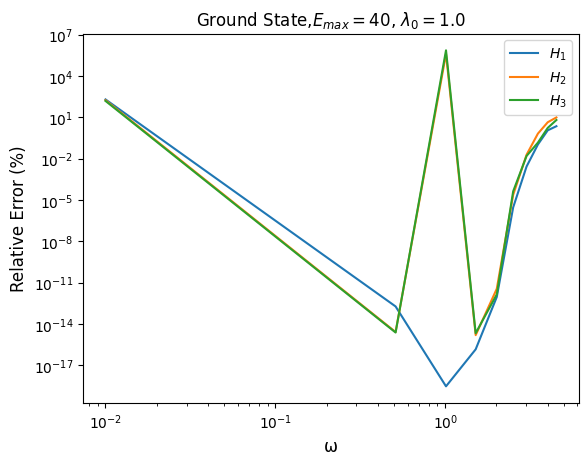

In [25]:
print(f"best error for H3 is {min(col(O_results_H3, 4))}")
print(f"best error for H2 is {min(col(O_results_H2, 4))}")
print(f"best error for H1 is {min(col(O_results_H1, 4))}")

plt.loglog(to_float_list(col(O_results_H1, 5)), to_float_list(col(O_results_H1, 4)), label=r"$H_1$")
plt.loglog(to_float_list(col(O_results_H2, 5)), to_float_list(col(O_results_H2, 4)), label=r"$H_2$")
plt.loglog(to_float_list(col(O_results_H3, 5)), to_float_list(col(O_results_H3, 4)), label=r"$H_3$")
plt.xlabel("ω", fontsize=fontsize)
plt.ylabel("Relative Error (%)", fontsize=fontsize)
plt.title(r"Ground State,$E_{max} = 40$, $\lambda_0 = 1.0$")
plt.legend()
plt.show()

In [26]:
Emax_List = [mp.mpf("1") + i *10 for i in range(9)]
omega = mp.mpf("0.6")

E_results_H1 = run_energy_scan(
    heff="H1",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

E_results_H2 = run_energy_scan(
    heff="H2",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

E_results_H3 = run_energy_scan(
    heff="H3",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List,
    Known_E=E0,
    print_table=True,
    hermitianize = False
)

H3_errors = col(E_results_H3, 4)
H2_errors = col(E_results_H2, 4)
H1_errors = col(E_results_H1, 4)

H3_argmin = min(range(len(H3_errors)), key=lambda i: H3_errors[i])
H2_argmin = min(range(len(H2_errors)), key=lambda i: H2_errors[i])
H1_argmin = min(range(len(H1_errors)), key=lambda i: H1_errors[i])

print(f"best error for H3 is {mp.nstr(H3_errors[H3_argmin], 20)} at {E_results_H3[H3_argmin][0]}")
print(f"best error for H2 is {mp.nstr(H2_errors[H2_argmin], 20)} at {E_results_H2[H2_argmin][0]}")
print(f"best error for H1 is {mp.nstr(H1_errors[H1_argmin], 20)} at {E_results_H1[H1_argmin][0]}")



omega=0.6  lambda=1.0
Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)
------------------------------------------------------------------------------------------
  1.00 |      2 | 0.653472222222,0.0 | 0.653472222222,0.0 | 23.8256
 11.00 |     18 | 0.527736132188,0.0 | 0.527736132188,0.0 | 9.23534e-7
 21.00 |     29 | 0.527736127317,0.0 | 0.527736127317,0.0 | 5.63957e-10
 31.00 |     39 | 0.527736127314,0.0 | 0.527736127314,0.0 | 9.91687e-14
 41.00 |     49 | 0.527736127314,0.0 | 0.527736127314,0.0 | 1.75825e-15
 51.00 |     59 | 0.527736127314,0.0 | 0.527736127314,0.0 | 6.06156e-18
 61.00 |     69 | 0.527736127314,0.0 | 0.527736127314,0.0 | 3.00667e-21
 71.00 |     79 | 0.527736127314,0.0 | 0.527736127314,0.0 | 4.57797e-22
 81.00 |     89 | 0.527736127314,0.0 | 0.527736127314,0.0 | 4.95111e-22
omega=0.6  lambda=1.0
Emax | dim(P) | E0_raw (Re,Im) | E0_HTET (Re,Im) | percentage error (rel to known)
--------------------------------------------------------

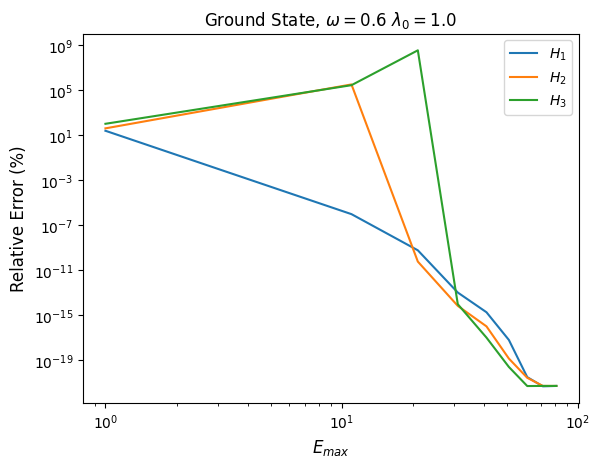

In [27]:
plt.loglog(to_float_list(col(E_results_H1, 0)), to_float_list(col(E_results_H1, 4)), label=r"$H_1$")
plt.loglog(to_float_list(col(E_results_H2, 0)), to_float_list(col(E_results_H2, 4)), label=r"$H_2$")
plt.loglog(to_float_list(col(E_results_H3, 0)), to_float_list(col(E_results_H3, 4)), label=r"$H_3$")

plt.xlabel(r"$E_{max}$", fontsize=fontsize)
plt.ylabel("Relative Error (%)", fontsize=fontsize)
plt.title(r"Ground State, $\omega = 0.6$ $\lambda_0 = 1.0$")
plt.legend()
plt.show()

lambda(Cohen)=1.0
Emax | omega | percentage error
----------------------------------------------------------------------
  1.00 |   0.3000 | 41.639
  1.00 |   0.8000 | 6.3653
  1.00 |   1.3000 | 1.52779
  1.00 |   1.8000 | 13.4154
 21.00 |   0.3000 | 8.46268e-5
 21.00 |   0.8000 | 3.0047e-11
 21.00 |   1.3000 | 5.43882e-10
 21.00 |   1.8000 | 1.6411e-7
 21.00 |   2.3000 | 0.00247648
 41.00 |   0.3000 | 1.7253e-8
 41.00 |   0.8000 | 2.05796e-21
 41.00 |   1.3000 | 9.47934e-19
 41.00 |   1.8000 | 6.8277e-16
 41.00 |   2.3000 | 4.21001e-11
 61.00 |   0.3000 | 2.87748e-12
 61.00 |   0.8000 | 4.94876e-22
 61.00 |   1.3000 | 4.94885e-22
 61.00 |   1.8000 | 4.4811e-22
 61.00 |   2.3000 | 1.87128e-17
 81.00 |   0.3000 | 9.95397e-15
 81.00 |   0.8000 | 4.94901e-22
 81.00 |   1.3000 | 4.94881e-22
 81.00 |   1.8000 | 4.94894e-22
 81.00 |   2.3000 | 4.67619e-22

H1: missing 1 grid points
First few missing points:
  Emax=1.0, omega=2.3
H1:
Minimum Percentage error = 4.48109941458674368883500726033e

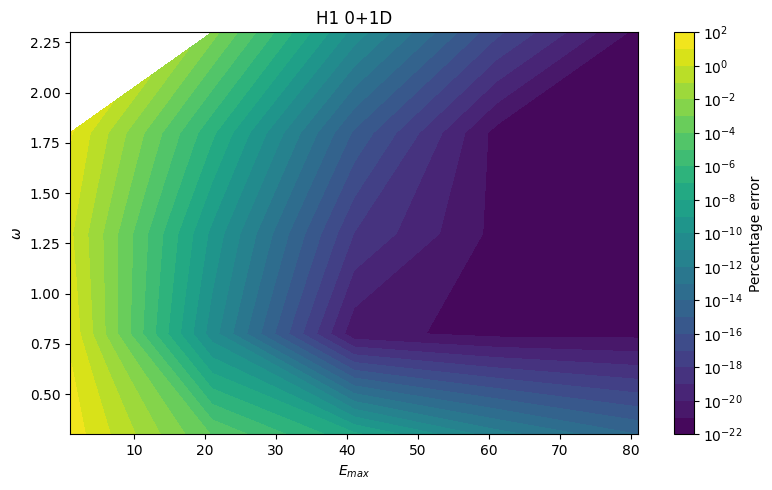

lambda(Cohen)=1.0
Emax | omega | percentage error
----------------------------------------------------------------------
  1.00 |   0.3000 | 20607.3
  1.00 |   0.8000 | 4.47229
  1.00 |   1.3000 | 0.159336
  1.00 |   1.8000 | 4.44399
 21.00 |   0.3000 | 9.08738e-6
 21.00 |   0.8000 | 277049.0
 21.00 |   1.3000 | 3.081e-9
 21.00 |   1.8000 | 4.9017e-7
 21.00 |   2.3000 | 0.00833091
 41.00 |   0.3000 | 4.35841e-9
 41.00 |   0.8000 | 3.52101e+6
 41.00 |   1.3000 | 23390.9
 41.00 |   1.8000 | 3.11363e-15
 41.00 |   2.3000 | 1.14476e-9
 61.00 |   0.3000 | 3.28897e-12
 61.00 |   0.8000 | 4.94921e-22
 61.00 |   1.3000 | 164203.0
 61.00 |   1.8000 | 1.23023e-21
 61.00 |   2.3000 | 2.01142e-16
 81.00 |   0.3000 | 6.59567e-16
 81.00 |   0.8000 | 4.94862e-22
 81.00 |   1.3000 | 562324.0
 81.00 |   1.8000 | 4.94898e-22
 81.00 |   2.3000 | 6.18632e-22

H2: missing 1 grid points
First few missing points:
  Emax=1.0, omega=2.3
H2:
Minimum Percentage error = 4.94862445823726678822216160693e-22
Occurs 

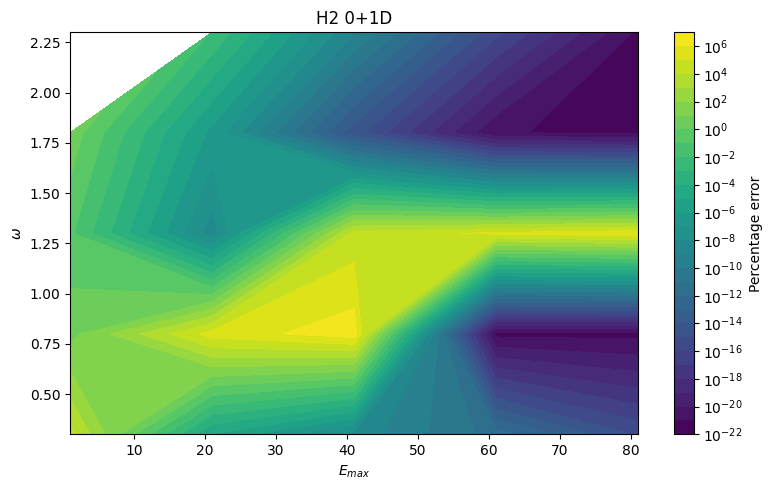

lambda(Cohen)=1.0
Emax | omega | percentage error
----------------------------------------------------------------------
  1.00 |   0.3000 | 193.795
  1.00 |   0.8000 | 4.70473
  1.00 |   1.3000 | 0.017071
  1.00 |   1.8000 | 1.71895
 21.00 |   0.3000 | 6.44561e-7
 21.00 |   0.8000 | 295194.0
 21.00 |   1.3000 | 1.99908e-9
 21.00 |   1.8000 | 2.03294e-7
 21.00 |   2.3000 | 0.00441604
 41.00 |   0.3000 | 2.56919e-10
 41.00 |   0.8000 | 2.6022e+7
 41.00 |   1.3000 | 3443.23
 41.00 |   1.8000 | 5.69472e-15
 41.00 |   2.3000 | 7.54884e-9
 61.00 |   0.3000 | 8.21555e-13
 61.00 |   0.8000 | 2.93095e+9
 61.00 |   1.3000 | 220898.0
 61.00 |   1.8000 | 3.30341e-21
 61.00 |   2.3000 | 4.85337e-16
 81.00 |   0.3000 | 1.20138e-15
 81.00 |   0.8000 | 4.9486e-22
 81.00 |   1.3000 | 1.52917e+6
 81.00 |   1.8000 | 4.94891e-22
 81.00 |   2.3000 | 7.34497e-22

H3: missing 1 grid points
First few missing points:
  Emax=1.0, omega=2.3
H3:
Minimum Percentage error = 4.94860465211361295480108929262e-22
Occu

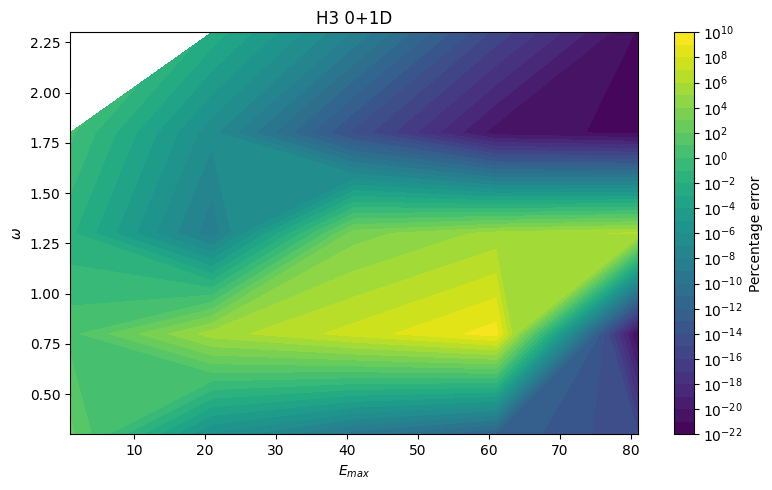


H1 global minimum
H1 minimum percentage error = 4.481099414586761e-22
Occurs at omega = 1.8, Emax = 61.0

H2 at omega ≈ 1.8
Using omega = 1.8
closest available error to H1 minimum:
  Emax = 81.0
  percentage error = 4.948978726260353e-22
  difference from H1 minimum = 4.6787931167359224e-23

H3 at omega ≈ 1.8
Using omega = 1.8
closest available error to H1 minimum:
  Emax = 81.0
  percentage error = 4.948913328682259e-22
  difference from H1 minimum = 4.678139140954985e-23


In [ ]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

Emax2 = [mp.mpf("1") + i * mp.mpf("20") for i in range(5)]
omega2 = [mp.mpf("0.3") + i * mp.mpf("0.5") for i in range(5)]

N_LEVELS = 100

contour_results_dict = {}
missing_points_dict = {}

for H in ["H1", "H2", "H3"]:
    res = run_emax_omega_scan(
        heff=H,
        omega_list=omega2,
        lam=1.0,
        Emax_list=Emax2,
        Known_E=E0,
        print_table=True,
        hermitianize=False
    )

    Emax_vals = sorted_unique(col(res, 0))
    omega_vals = sorted_unique(col(res, 1))

    # Build index lookups
    emax_to_j = {float(x): j for j, x in enumerate(Emax_vals)}
    omega_to_i = {float(y): i for i, y in enumerate(omega_vals)}

    # Start with a grid full of NaNs
    Z = [[mp.nan for _ in range(len(Emax_vals))] for _ in range(len(omega_vals))]

    # Fill grid from available results
    # Assumes row structure: [Emax, omega, percentage_error, ...]
    for row in res:
        emax, omega, z = row[0], row[1], row[2]
        i = omega_to_i[float(omega)]
        j = emax_to_j[float(emax)]
        Z[i][j] = z

    # Find missing grid points
    missing_points = []
    for i, omega in enumerate(omega_vals):
        for j, emax in enumerate(Emax_vals):
            if mp.isnan(Z[i][j]):
                missing_points.append((emax, omega))

    missing_points_dict[H] = missing_points

    if missing_points:
        print(f"\n{H}: missing {len(missing_points)} grid points")
        print("First few missing points:")
        for emax, omega in missing_points[:10]:
            print(f"  Emax={emax}, omega={omega}")
    else:
        print(f"\n{H}: full grid present")

    # Keep only finite positive values; leave everything else as NaN
    Z_clean = []
    for row in Z:
        new_row = []
        for z in row:
            if (not mp.isnan(z)) and mp.isfinite(z) and z > 0:
                new_row.append(z)
            else:
                new_row.append(mp.nan)
        Z_clean.append(new_row)

    # Find best finite positive value from original cleaned grid
    valid_entries = []
    for i in range(len(omega_vals)):
        for j in range(len(Emax_vals)):
            z = Z_clean[i][j]
            if (not mp.isnan(z)) and mp.isfinite(z) and z > 0:
                valid_entries.append((i, j, z))

    if valid_entries:
        row_idx, col_idx, min_error = min(valid_entries, key=lambda t: t[2])
        best_omega = omega_vals[row_idx]
        best_Emax = Emax_vals[col_idx]
        Z_valid = [t[2] for t in valid_entries]
        median_log_error = 10 ** (sum(mp.log10(z) for z in Z_valid) / len(Z_valid))
        mean_z = sum(Z_valid) / len(Z_valid)
        std_error = mp.sqrt(sum((z - mean_z) ** 2 for z in Z_valid) / len(Z_valid))

        min_log10 = min(mp.log10(z) for z in Z_valid)
        max_log10 = max(mp.log10(z) for z in Z_valid)
    else:
        min_error = mp.nan
        best_omega = mp.nan
        best_Emax = mp.nan
        median_log_error = mp.nan
        std_error = mp.nan
        min_log10 = mp.nan
        max_log10 = mp.nan

    print(f"{H}:")
    print(f"Minimum Percentage error = {min_error}")
    print(f"Occurs at Emax = {best_Emax}, Omega = {best_omega}")
    print(f"Median Percentage error  = {median_log_error} with std = {std_error}")
    print(f"log10(error) range = [{min_log10}, {max_log10}]")

    # Convert axes to floats
    Xf = np.array([float(x) for x in Emax_vals], dtype=float)
    Yf = np.array([float(y) for y in omega_vals], dtype=float)

    # Build log10(error) grid directly, leaving invalid points as NaN
    Zlog = []
    for row in Z_clean:
        new_row = []
        for z in row:
            if (not mp.isnan(z)) and mp.isfinite(z) and z > 0:
                new_row.append(float(mp.log10(z)))
            else:
                new_row.append(np.nan)
        Zlog.append(new_row)

    Zlog = np.array(Zlog, dtype=float)
    Zmasked = np.ma.masked_invalid(Zlog)

    contour_results_dict[H] = (Xf, Yf, Zlog)

    fig, ax = plt.subplots(figsize=(8, 5))

    finite_logs = Zlog[np.isfinite(Zlog)]
    if finite_logs.size == 0:
        raise ValueError(f"No finite log10(error) values available to plot for {H}")

    # Use integer decades as the actual contour boundaries
    level_min = int(np.floor(finite_logs.min()))
    level_max = int(np.ceil(finite_logs.max()))
    levels = np.arange(level_min, level_max + 1, 1)

    cf = ax.contourf(
        Xf,
        Yf,
        Zmasked,
        levels=levels,
        vmin=level_min,
        vmax=level_max
    )

    cbar = fig.colorbar(cf, ax=ax, boundaries=levels)
    cbar.set_label("Percentage error")

    # Put ticks only where levels actually exist
    tick_locs = np.arange(level_min, level_max + 1, 2)
    cbar.set_ticks(tick_locs)
    cbar.set_ticklabels([rf"$10^{{{n}}}$" for n in tick_locs])

    ax.set_title(f"{H} 0+1D")
    ax.set_xlabel(r"$E_{max}$")
    ax.set_ylabel(r"$\omega$")

    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Extra comparison:
# 1) Find overall minimum percentage error for H1 and its (omega, Emax)
# 2) At that SAME omega, find the smallest Emax for H2/H3 whose error
#    is <= the H1 minimum error. If none exist, report the closest one.
# ------------------------------------------------------------

def nearest_index(arr, value):
    arr = np.asarray(arr, dtype=float)
    return int(np.argmin(np.abs(arr - float(value))))

# H1 global minimum
Xf_H1, Yf_H1, Zlog_H1 = contour_results_dict["H1"]
finite_idx_H1 = np.argwhere(np.isfinite(Zlog_H1))

if finite_idx_H1.size == 0:
    raise ValueError("No finite H1 values found.")

i_H1_min, j_H1_min = min(
    finite_idx_H1,
    key=lambda idx: Zlog_H1[idx[0], idx[1]]
)

H1_min_log10 = Zlog_H1[i_H1_min, j_H1_min]
H1_min_error = 10 ** H1_min_log10
H1_best_omega = Yf_H1[i_H1_min]
H1_best_Emax = Xf_H1[j_H1_min]

print("\n" + "=" * 60)
print("H1 global minimum")
print(f"H1 minimum percentage error = {H1_min_error}")
print(f"Occurs at omega = {H1_best_omega}, Emax = {H1_best_Emax}")

# H2 and H3 at same omega as H1 optimum
for H in ["H2", "H3"]:
    Xf, Yf, Zlog = contour_results_dict[H]

    i_same_omega = nearest_index(Yf, H1_best_omega)
    omega_used = Yf[i_same_omega]
    row_logs = Zlog[i_same_omega, :]

    finite_js = [j for j in range(len(Xf)) if np.isfinite(row_logs[j])]
    if not finite_js:
        print(f"\n{H}: no finite values found at omega ≈ {H1_best_omega}")
        continue

    # First try to find the smallest Emax that achieves error <= H1 minimum
    eligible_js = [j for j in finite_js if (10 ** row_logs[j]) <= H1_min_error]

    if eligible_js:
        j_match = min(eligible_js, key=lambda j: Xf[j])
        match_type = "smallest Emax achieving error <= H1 minimum"
    else:
        # Fallback: choose the closest error if exact/better match does not exist
        row_errors = np.array([10 ** row_logs[j] for j in finite_js], dtype=float)
        best_local_idx = int(np.argmin(np.abs(row_errors - H1_min_error)))
        j_match = finite_js[best_local_idx]
        match_type = "closest available error to H1 minimum"

    matched_Emax = Xf[j_match]
    matched_error = 10 ** row_logs[j_match]

    print(f"\n{H} at omega ≈ {H1_best_omega}")
    print(f"Using omega = {omega_used}")
    print(f"{match_type}:")
    print(f"  Emax = {matched_Emax}")
    print(f"  percentage error = {matched_error}")
    print(f"  difference from H1 minimum = {abs(matched_error - H1_min_error)}")

print("=" * 60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, wspace=0.0, hspace=0.0)

ax_H1 = fig.add_subplot(gs[0, 0])
ax_H2 = fig.add_subplot(gs[0, 1])
ax_H3 = fig.add_subplot(gs[1, 0])

axes = {
    "H1": ax_H1,
    "H2": ax_H2,
    "H3": ax_H3,
}

# ------------------------------------------------------------
# Find common finite log10(error) range across all three plots
# ------------------------------------------------------------
all_finite_logs = []
for H in ["H1", "H2", "H3"]:
    Xf, Yf, Zlog = contour_results_dict[H]
    finite_vals = Zlog[np.isfinite(Zlog)]
    all_finite_logs.extend(finite_vals)

if len(all_finite_logs) == 0:
    raise ValueError("No finite log10(error) values found in contour_results_dict.")

all_finite_logs = np.array(all_finite_logs, dtype=float)

level_min = int(np.floor(all_finite_logs.min()))
level_max = int(np.ceil(all_finite_logs.max()))

# integer-decade contour boundaries
levels = np.arange(level_min, level_max + 1, 1)

# ------------------------------------------------------------
# Plot each Hamiltonian
# ------------------------------------------------------------
cf = None

for H, ax in axes.items():
    Xf, Yf, Zlog = contour_results_dict[H]

    # Mask invalid points so missing grid points are left blank
    Zmasked = np.ma.masked_invalid(Zlog)

    cf = ax.contourf(
        Xf,
        Yf,
        Zmasked,
        levels=levels,
        vmin=level_min,
        vmax=level_max
    )

    ax.text(
        0, 0.98,
        f"{H}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        color="black"
    )

    if ax is ax_H1:
        ax.tick_params(labelbottom=False)

    if ax is ax_H2:
        ax.set_xlabel(r"$E_{max}$", fontsize=fontsize)
        ax.tick_params(labelbottom=True)
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

ax_H1.set_ylabel(r"$\omega$", fontsize=fontsize)
ax_H3.set_ylabel(r"$\omega$", fontsize=fontsize)
ax_H3.set_xlabel(r"$E_{max}$", fontsize=fontsize)

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(cf, ax=[ax_H1, ax_H2, ax_H3], shrink=0.9, boundaries=levels)
cbar.set_label("Relative error (%)", fontsize=fontsize)

tick_locs = np.arange(level_min, level_max + 1, 2)
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([rf"$10^{{{n}}}$" for n in tick_locs])


fig.suptitle(r"Ground State, $\lambda_0 = 1$", y= 0.91, x=0.45)

fig.savefig(
    "HTET.png",  # PDF is best for papers
    dpi=300,
    bbox_inches="tight"
)

plt.show()